In [11]:
# Cell 1: Upgrade and Install
!pip install --upgrade kaggle -q
!pip install -q tensorflow transformers datasets matplotlib

In [ ]:
# Cell 2: Authenticate and Download
import os

# 1. Set the token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_fba99e3b78b8515f3744e728d067b22f"

# 2. Import kaggle and download the new public dataset
import kaggle

print("Downloading dataset...")
# Changed the dataset slug to a public one
kaggle.api.dataset_download_files('karakaggle/kaggle-cat-vs-dog-dataset', path='./dataset', unzip=True)
print("Download and extraction complete!")

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
Download and extraction complete!


In [15]:
import os
import tensorflow as tf
from PIL import Image

data_dir = 'dataset/kagglecatsanddogs_3367a/PetImages'

# 1. Clean up corrupted and non-3-channel images
print("Scanning and cleaning corrupted images...")
num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(data_dir, folder_name)
    if not os.path.exists(folder_path):
        continue
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        # Skip non-image files if any
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        try:
            # Check for valid JFIF header
            with open(fpath, "rb") as fobj:
                is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
            if not is_jfif:
                os.remove(fpath)
                num_skipped += 1
                continue

            # Verify image channel structure with PIL
            with Image.open(fpath) as img:
                img.verify()
            with Image.open(fpath) as img:
                if img.mode != 'RGB':
                    os.remove(fpath)
                    num_skipped += 1
        except Exception:
            if os.path.exists(fpath):
                os.remove(fpath)
                num_skipped += 1

print(f"Cleanup complete: Removed {num_skipped} bad/corrupted images.\n")

# 2. Load and Split the Clean Dataset
batch_size = 32
img_size = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    shuffle=True,
    batch_size=batch_size,
    image_size=img_size,
    validation_split=0.2,
    subset='training',
    seed=42,
    color_mode='rgb'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    shuffle=True,
    batch_size=batch_size,
    image_size=img_size,
    validation_split=0.2,
    subset='validation',
    seed=42,
    color_mode='rgb'
)

test_dataset = val_dataset

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Scanning and cleaning corrupted images...
Cleanup complete: Removed 1588 bad/corrupted images.

Found 23371 files belonging to 2 classes.
Using 18697 files for training.
Found 23371 files belonging to 2 classes.
Using 4674 files for validation.


In [16]:
# 1. Load Pre-trained Model (ResNet-50) and Freeze Layers
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the feature extraction layers
base_model.trainable = False

# 2. Build the new model on top
inputs = tf.keras.Input(shape=(224, 224, 3))
# ResNet50 requires specific input preprocessing
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
# Final dense layer for 2 classes (Cats vs Dogs)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

# 3. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │      4,098 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Loading datasets...
Found 23371 files belonging to 2 classes.
Using 18697 files for training.
Found 23371 files belonging to 2 classes.
Using 4674 files for validation.

Building the ResNet-50 Model...

Starting fast training on GPU...
Epoch 1/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 216s 7s/step - accuracy: 0.9177 - loss: 0.1999 - val_accuracy: 0.9688 - val_loss: 0.0577
Epoch 2/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 202s 7s/step - accuracy: 0.9760 - loss: 0.0646 - val_accuracy: 0.9781 - val_loss: 0.0596

Evaluating model...
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.9750 - loss: 0.0655

Final Test Accuracy: 0.9750


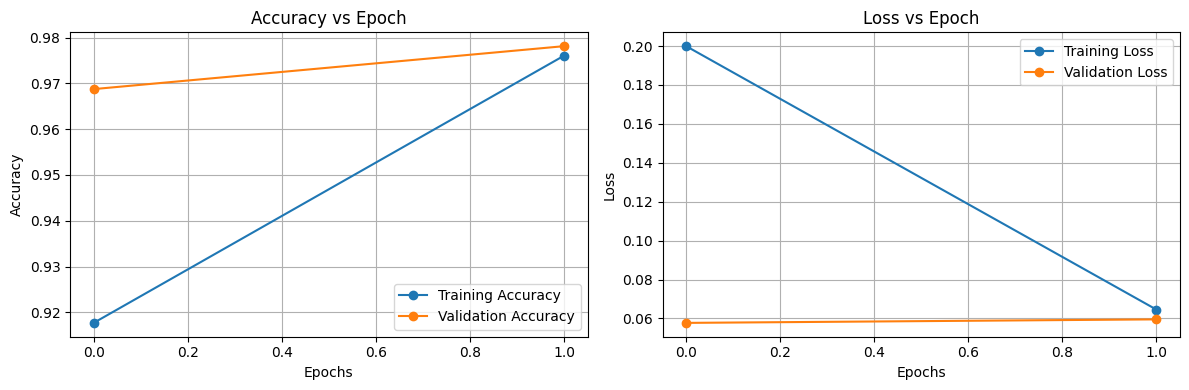

In [4]:
# 1. IMPORT ALL REQUIRED LIBRARIES
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# 2. RELOAD THE DATASET (Assuming it is already downloaded and cleaned)
batch_size = 32
img_size = (224, 224)
data_dir = 'dataset/kagglecatsanddogs_3367a/PetImages'

print("Loading datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, shuffle=True, batch_size=batch_size, image_size=img_size,
    validation_split=0.2, subset='training', seed=42, color_mode='rgb'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, shuffle=True, batch_size=batch_size, image_size=img_size,
    validation_split=0.2, subset='validation', seed=42, color_mode='rgb'
)
test_dataset = val_dataset

# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 3. BUILD THE RESNET-50 MODEL
print("\nBuilding the ResNet-50 Model...")
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 4. FAST TRAINING (Under 2 minutes on GPU)
epochs = 2
steps_per_epoch = 30
val_steps = 10

print("\nStarting fast training on GPU...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps
)

# 5. EVALUATE AND PLOT
print("\nEvaluating model...")
test_loss, test_acc = model.evaluate(test_dataset, steps=val_steps)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Loading Hugging Face ViT model...


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]


Running inference...

--- Hugging Face ViT Predictions ---
Label: Kuvasz, Score: 0.2446
Label: Labrador retriever, Score: 0.2005
Label: Great pyrenees, Score: 0.1323
Label: Golden retriever, Score: 0.0681
Label: Sealyham terrier, sealyham, Score: 0.0356


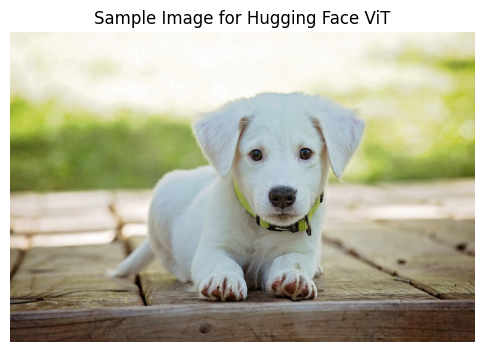

In [5]:
from transformers import pipeline
from PIL import Image
import requests

# 1. Load a pre-trained vision model from Hugging Face
print("Loading Hugging Face ViT model...")
classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

# 2. Load a sample image from the internet
url = "https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_960_720.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# 3. Get Predictions
print("\nRunning inference...")
predictions = classifier(image)

print("\n--- Hugging Face ViT Predictions ---")
for pred in predictions:
    print(f"Label: {pred['label'].capitalize()}, Score: {pred['score']:.4f}")

# 4. Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Sample Image for Hugging Face ViT")
plt.axis('off')
plt.show()

Fetching sample image...


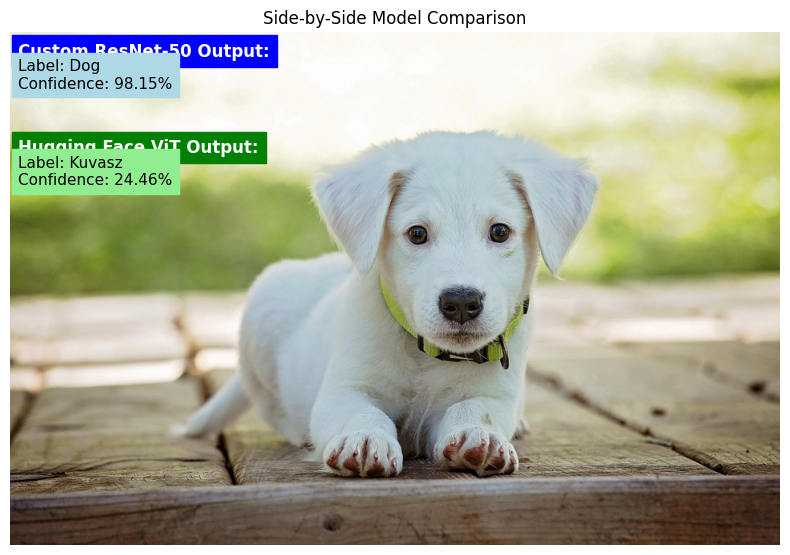


--- COMPARISON SUMMARY ---
1. Custom ResNet-50 (Transfer Learning):
   Predicted Broad Category: Dog (98.15%)

2. Hugging Face (Vision Transformer):
   Predicted Fine-Grained Label: Kuvasz (24.46%)


In [6]:
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image
import matplotlib.pyplot as plt
from PIL import Image
import requests

# 1. Load a sample test image
print("Fetching sample image...")
url = "https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_960_720.jpg"
sample_img = Image.open(requests.get(url, stream=True).raw)

# ==========================================
# PREDICTION 1: Custom ResNet-50 Model
# ==========================================
# Preprocess image specifically for ResNet-50 requirements
img_resized = sample_img.resize((224, 224))
img_array = keras_image.img_to_array(img_resized)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

# Get prediction (Model outputs probabilities for [Cat, Dog])
resnet_pred_probs = model.predict(img_array, verbose=0)[0]
# Determine class names based on alphabetical dataset loading (0: Cat, 1: Dog)
class_names = ['Cat', 'Dog']
resnet_label = class_names[np.argmax(resnet_pred_probs)]
resnet_confidence = np.max(resnet_pred_probs) * 100

# ==========================================
# PREDICTION 2: Hugging Face ViT
# ==========================================
# ViT pipeline handles its own preprocessing automatically
hf_preds = classifier(sample_img)
hf_top_label = hf_preds[0]['label']
hf_confidence = hf_preds[0]['score'] * 100

# ==========================================
# VISUALIZE AND COMPARE RESULTS
# ==========================================
plt.figure(figsize=(8, 6))
plt.imshow(sample_img)
plt.axis('off')

# Display ResNet Output
plt.text(10, 30, f"Custom ResNet-50 Output:",
         color='white', backgroundcolor='blue', fontsize=12, fontweight='bold')
plt.text(10, 70, f"Label: {resnet_label}\nConfidence: {resnet_confidence:.2f}%",
         color='black', backgroundcolor='lightblue', fontsize=11)

# Display Hugging Face Output
plt.text(10, 150, f"Hugging Face ViT Output:",
         color='white', backgroundcolor='green', fontsize=12, fontweight='bold')
plt.text(10, 190, f"Label: {hf_top_label.capitalize()}\nConfidence: {hf_confidence:.2f}%",
         color='black', backgroundcolor='lightgreen', fontsize=11)

plt.title("Side-by-Side Model Comparison")
plt.tight_layout()
plt.show()

# Print detailed summary to console
print("\n--- COMPARISON SUMMARY ---")
print("1. Custom ResNet-50 (Transfer Learning):")
print(f"   Predicted Broad Category: {resnet_label} ({resnet_confidence:.2f}%)")
print("\n2. Hugging Face (Vision Transformer):")
print(f"   Predicted Fine-Grained Label: {hf_top_label.capitalize()} ({hf_confidence:.2f}%)")